# Step 3 — 正常訂單瓶頸拆解

**目標**：排除異常後，分析正常訂單的 phase breakdown

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
REPORTS_DIR = Path('../reports')

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
sys_flags = pd.read_csv('../data/system_anomaly_flags.csv')
usr_flags = pd.read_csv('../data/user_anomaly_flags.csv')
df = df.merge(sys_flags, on='order_id').merge(usr_flags, on='order_id')

normal = df[~(df['is_system_anomaly'] | df['is_user_anomaly'])].copy()
print(f"Total: {len(df):,}, Normal: {len(normal):,} ({100*len(normal)/len(df):.1f}%)")


Total: 30,000, Normal: 29,061 (96.9%)


## Phase Estimation + Model Validation

Orders per group:
fc_group
<100         10489
100-1000     14235
1000-2000     3157
2000+         1180
Name: count, dtype: int64


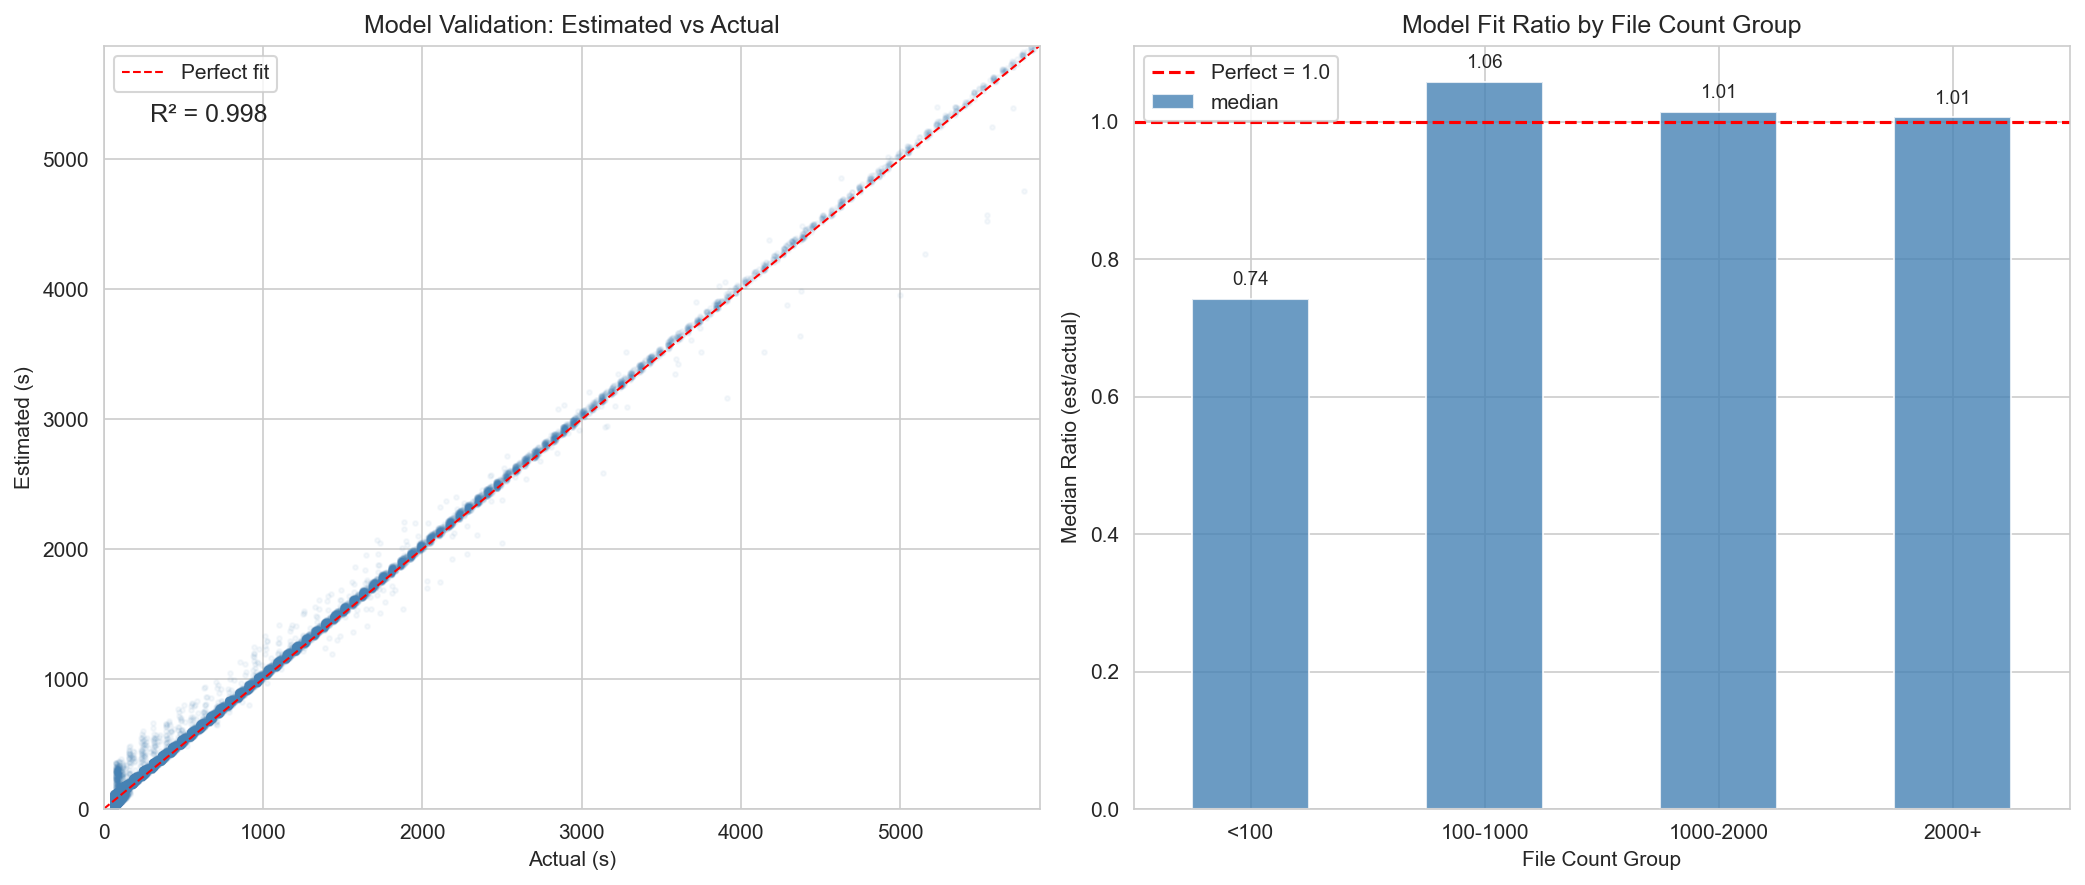


Model R²: 0.998
Ratio by group:
             median      mean  count
fc_group                            
<100       0.742537  0.826489  10489
100-1000   1.058077  1.105835  14235
1000-2000  1.014588  1.015741   3157
2000+      1.006457  1.005430   1180


In [3]:
# Phase estimation
normal['est_queue'] = normal['queue_duration_seconds']
normal['est_db'] = normal['db_duration_avg_seconds'] * normal['file_count'] / PARALLELISM
normal['est_device'] = normal['device_duration_avg_seconds'] * normal['file_count'] / PARALLELISM
normal['est_inner'] = normal['inner_processing_duration_avg_seconds'] * normal['file_count'] / PARALLELISM
normal['est_total'] = normal['est_queue'] + normal['est_db'] + normal['est_device'] + normal['est_inner']
normal['ratio'] = normal['est_total'] / normal['total_duration_seconds']

normal['fc_group'] = pd.cut(normal['file_count'], bins=FILE_COUNT_BINS, labels=FILE_COUNT_LABELS, right=True)

print("Orders per group:")
print(normal['fc_group'].value_counts().sort_index())

# R²
ss_res = ((normal['est_total'] - normal['total_duration_seconds']) ** 2).sum()
ss_tot = ((normal['total_duration_seconds'] - normal['total_duration_seconds'].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

# Model validation chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
max_val = max(normal['total_duration_seconds'].quantile(0.99), normal['est_total'].quantile(0.99))
ax.scatter(normal['total_duration_seconds'], normal['est_total'], alpha=0.05, s=5, c='steelblue')
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect fit')
ax.set_title('Model Validation: Estimated vs Actual')
ax.set_xlabel('Actual (s)')
ax.set_ylabel('Estimated (s)')
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.text(0.05, 0.9, f'R² = {r2:.3f}', transform=ax.transAxes, fontsize=12)
ax.legend()

ratio_by_group = normal.groupby('fc_group', observed=True)['ratio'].agg(['median', 'mean', 'count'])
ratio_by_group['median'].plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.8)
axes[1].axhline(y=1.0, color='red', linestyle='--', label='Perfect = 1.0')
axes[1].set_title('Model Fit Ratio by File Count Group')
axes[1].set_xlabel('File Count Group')
axes[1].set_ylabel('Median Ratio (est/actual)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()
for i, (idx, row) in enumerate(ratio_by_group.iterrows()):
    axes[1].text(i, row['median'] + 0.02, f'{row["median"]:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_model_validation.png', dpi=150)
plt.show()

print(f"\nModel R²: {r2:.3f}")
print(f"Ratio by group:")
print(ratio_by_group.to_string())

if r2 < 0.9:
    print(f"\n⚠️  R² < 0.9，可能 PARALLELISM 不正確，或有未考慮的 overhead")


## Phase Proportion

Phase proportion (%):
           Queue    DB  Device  Inner Processing
fc_group                                        
<100        28.7  19.9    36.3              15.2
100-1000     3.2  27.3    48.7              20.8
1000-2000    0.9  28.0    49.7              21.3
2000+        0.4  28.5    49.5              21.6

Phase absolute means (seconds):
           Queue      DB  Device  Inner Processing
fc_group                                          
<100        19.4    13.5    24.6              10.3
100-1000    19.1   164.9   293.9             125.2
1000-2000   19.1   573.3  1017.0             436.1
2000+       19.5  1334.7  2319.0            1013.7


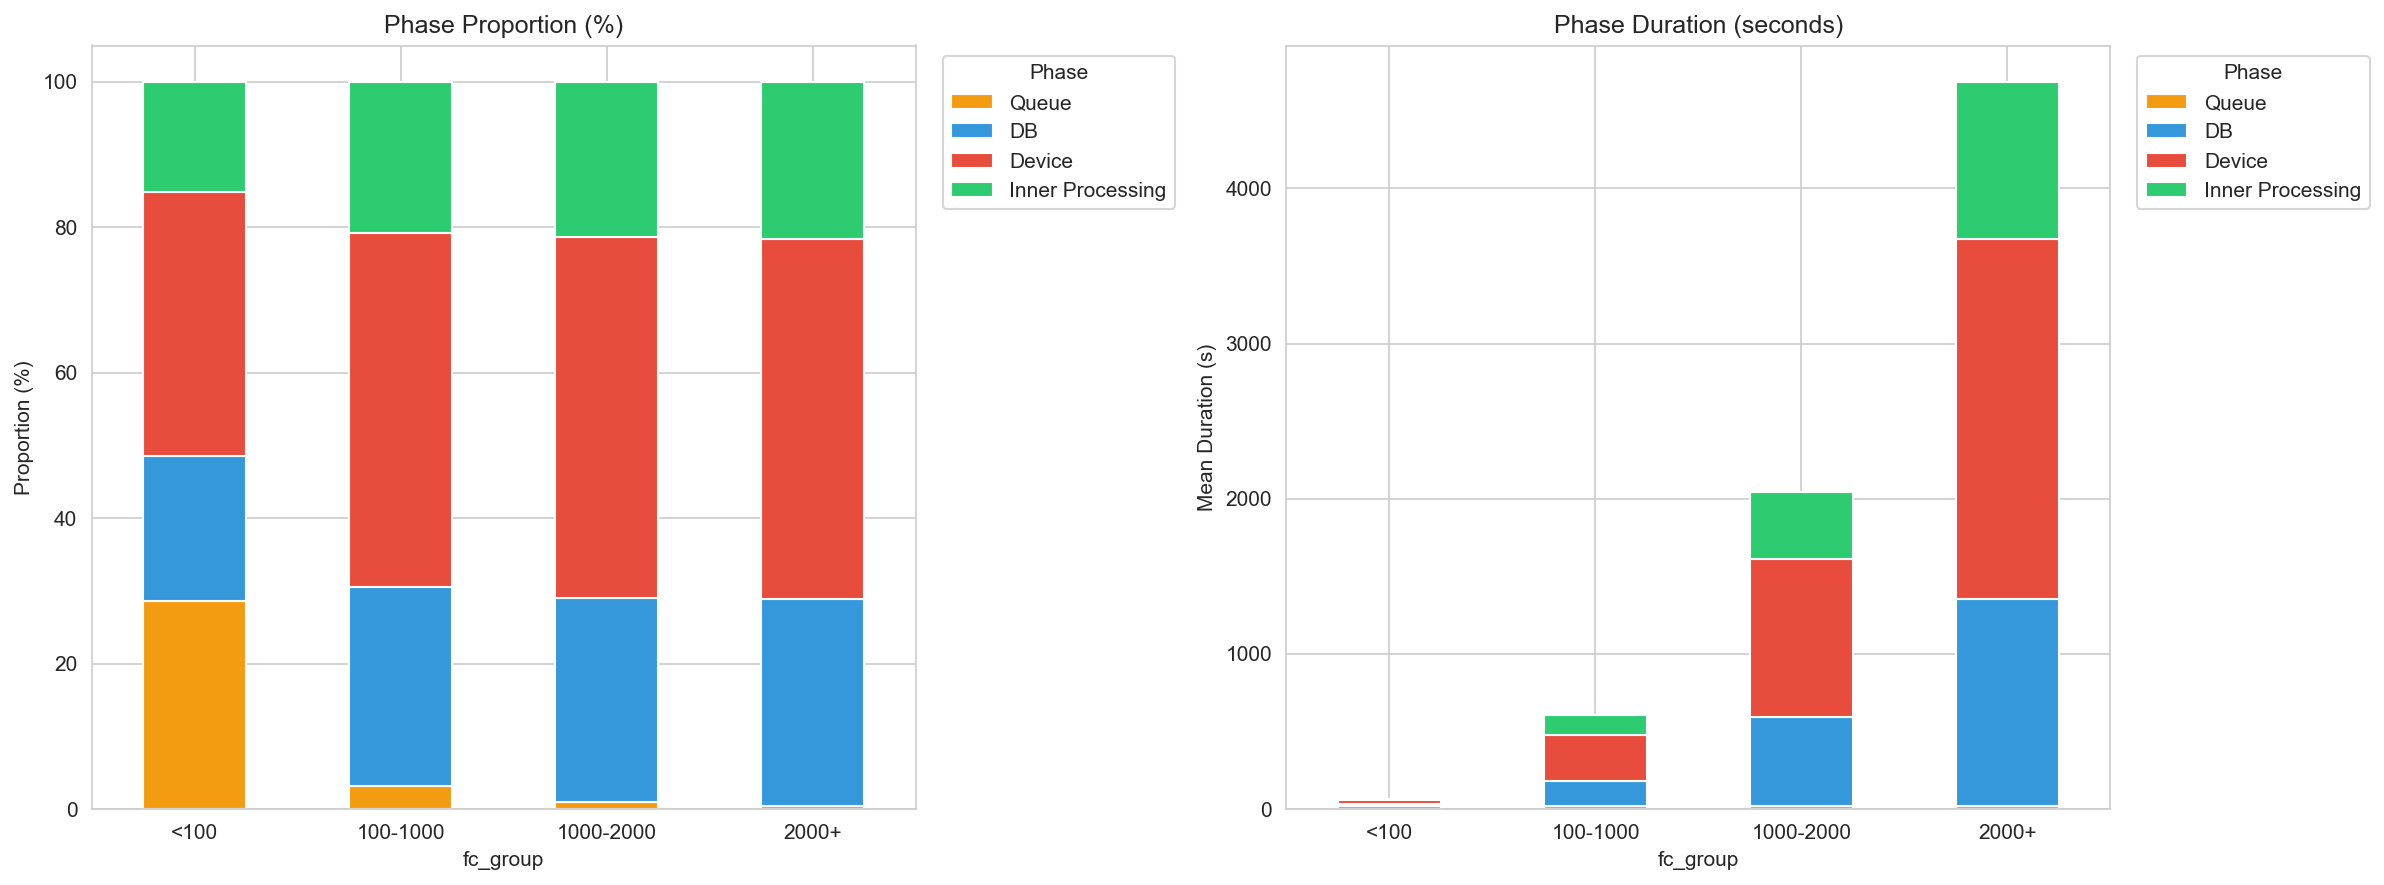

In [4]:
phase_cols = ['est_queue', 'est_db', 'est_device', 'est_inner']
phase_labels = ['Queue', 'DB', 'Device', 'Inner Processing']

group_means = normal.groupby('fc_group', observed=True)[phase_cols].mean()
group_means.columns = phase_labels
group_pct = group_means.div(group_means.sum(axis=1), axis=0) * 100

print("Phase proportion (%):")
print(group_pct.round(1).to_string())
print()
print("Phase absolute means (seconds):")
print(group_means.round(1).to_string())

# Stacked bars
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#f39c12', '#3498db', '#e74c3c', '#2ecc71']

group_pct.plot(kind='bar', stacked=True, ax=axes[0], color=colors)
axes[0].set_title('Phase Proportion (%)')
axes[0].set_ylabel('Proportion (%)')
axes[0].legend(title='Phase', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=0)

group_means.plot(kind='bar', stacked=True, ax=axes[1], color=colors)
axes[1].set_title('Phase Duration (seconds)')
axes[1].set_ylabel('Mean Duration (s)')
axes[1].legend(title='Phase', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_phase_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()


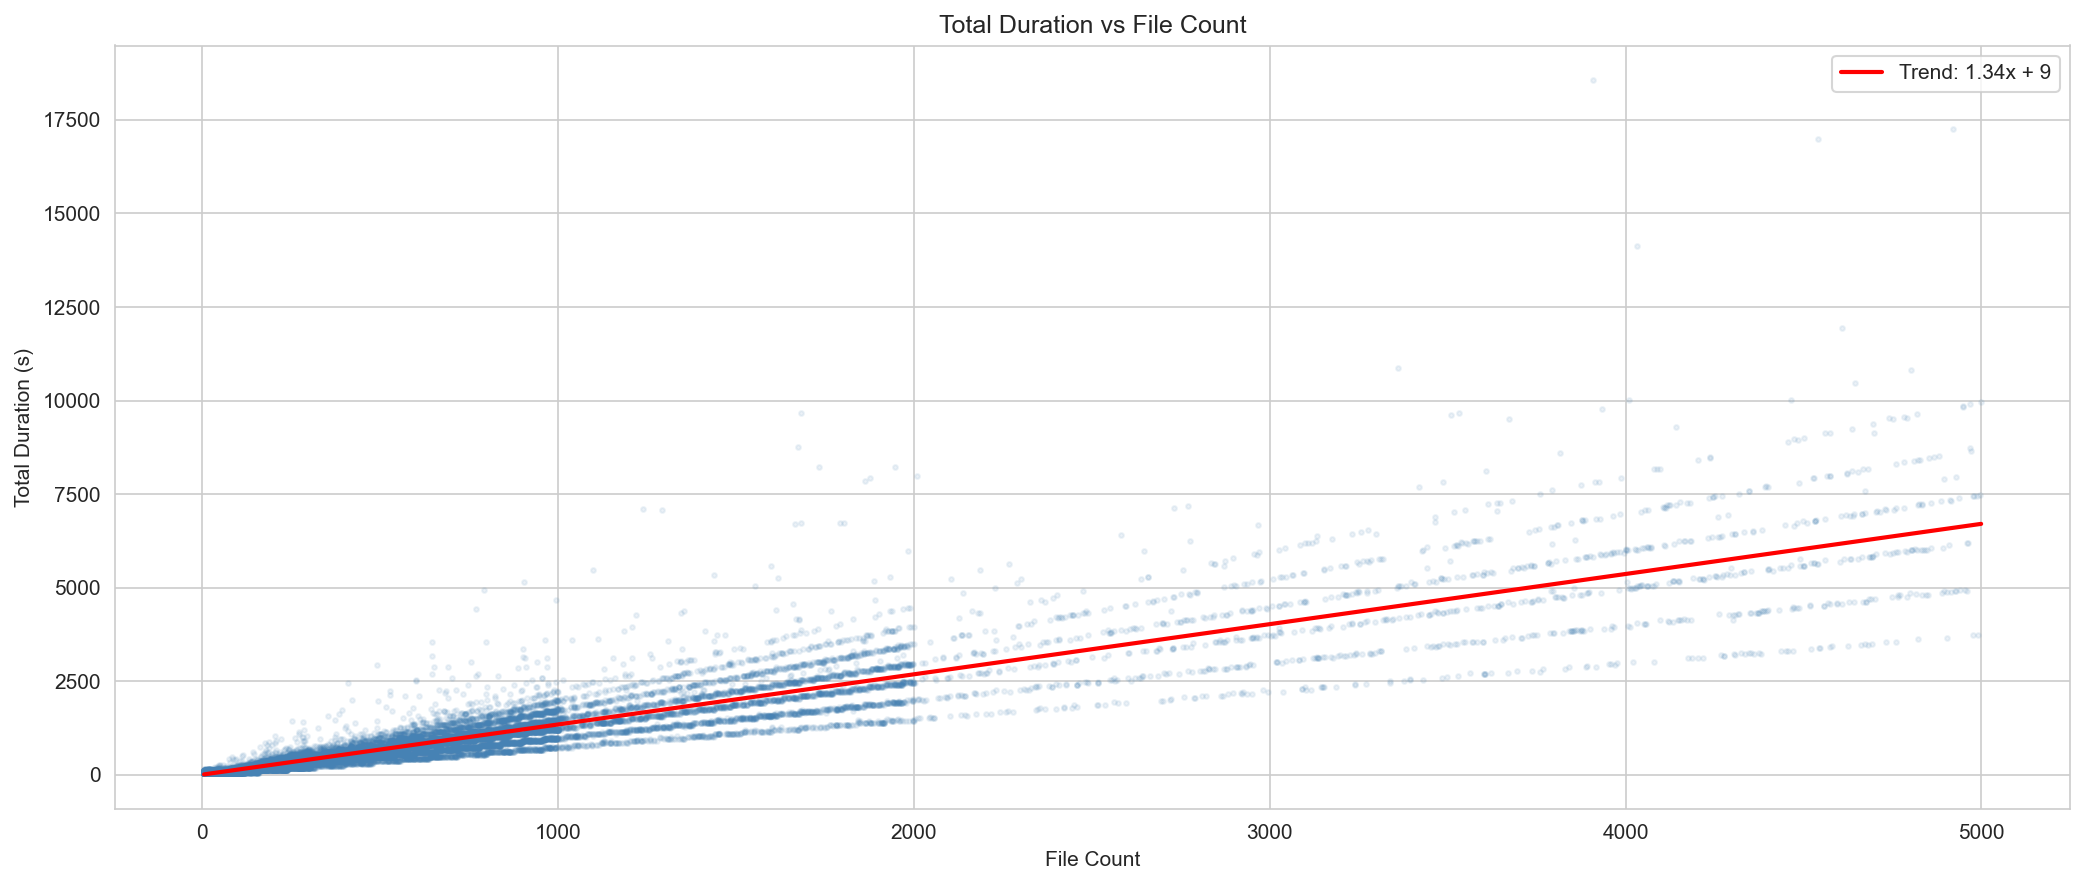

In [5]:
# Duration vs file_count scatter
fig, ax = plt.subplots(figsize=(14, 6))
ax.scatter(normal['file_count'], normal['total_duration_seconds'], alpha=0.1, s=5, c='steelblue')
z = np.polyfit(normal['file_count'], normal['total_duration_seconds'], 1)
x_line = np.linspace(normal['file_count'].min(), normal['file_count'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), 'r-', linewidth=2, label=f'Trend: {z[0]:.2f}x + {z[1]:.0f}')
ax.set_title('Total Duration vs File Count')
ax.set_xlabel('File Count')
ax.set_ylabel('Total Duration (s)')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step3_duration_vs_filecount.png', dpi=150)
plt.show()


## Summary

In [6]:
biggest = group_pct.idxmax(axis=1)
print("=== Step 3 Summary ===")
print(f"Normal orders: {len(normal):,}")
print(f"Model R²: {r2:.3f}")
print(f"Params: PARALLELISM={PARALLELISM}, bins={FILE_COUNT_BINS}")
print(f"\nDominant phase per group:")
for g, phase in biggest.items():
    print(f"  {g}: {phase} ({group_pct.loc[g, phase]:.1f}%)")
print(f"\nOverall dominant: {group_pct.mean().idxmax()} ({group_pct.mean().max():.1f}% avg)")


=== Step 3 Summary ===
Normal orders: 29,061
Model R²: 0.998
Params: PARALLELISM=4, bins=[0, 100, 1000, 2000, 100000]

Dominant phase per group:
  <100: Device (36.3%)
  100-1000: Device (48.7%)
  1000-2000: Device (49.7%)
  2000+: Device (49.5%)

Overall dominant: Device (46.0% avg)


In [7]:
# Export summary to reports/
summary = []
summary.append("=" * 60)
summary.append("Step 3 — Bottleneck Breakdown")
summary.append("=" * 60)
summary.append(f"\nNormal orders: {len(normal):,}  （排除異常後的正常訂單數）")
summary.append(f"Model R²: {r2:.3f}  （phase model 的擬合度，>0.9 表示模型有效）")
summary.append(f"PARALLELISM={PARALLELISM}  （每筆 order 的並行 thread 數）")
summary.append(f"FILE_COUNT_BINS={FILE_COUNT_BINS}")
summary.append(f"\n--- Dominant Phase ---  （每個 file_count 組別中，哪個階段佔最大比例）")
for g, phase in biggest.items():
    summary.append(f"  {g}: {phase} ({group_pct.loc[g, phase]:.1f}%)")
summary.append(f"\nOverall dominant: {group_pct.mean().idxmax()} ({group_pct.mean().max():.1f}% avg)")
summary.append(f"  （整體來看佔比最大的階段 → 優化的首要目標）")
summary.append(f"\n--- Phase Proportion (%) ---  （各階段佔 order 總耗時的百分比）")
summary.append(f"  Queue:  等 consumer 撿起訂單的時間")
summary.append(f"  DB:     查詢 golden file list 的時間")
summary.append(f"  Device: 對設備下 command 取得 file 的時間")
summary.append(f"  Inner:  file check 處理時間")
summary.append(group_pct.round(1).to_string())
summary.append(f"\n--- Phase Absolute Means (seconds) ---  （各階段的平均絕對耗時）")
summary.append(group_means.round(1).to_string())

with open(str(REPORTS_DIR / 'step3_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step3_summary.txt")


Saved: reports/step3_summary.txt
